In [32]:
from time import time

import matplotlib.pyplot as plt
import numpy as np
from hetero_isas.monodromy_lp import (
    MonodromyLPDecomposer,
)
from hetero_isas.monodromy_lp.decomposer import MonodromyLPDecomposerResult
from hetero_isas.monodromy_lp.invariants import recover_local_equivalence
from hetero_isas.monodromy_lp.isa import ISAHandler
from hetero_isas.monodromy_lp.mono_lp_result import plot_histograms
from hetero_isas.zz_parallel_drive.ansatz import BasicCircuitAnsatz
from numpy.random import Philox
from qiskit import QuantumCircuit
from qiskit.circuit import Gate, Parameter
from qiskit.circuit.library import CXGate, CZGate, SwapGate, UnitaryGate, iSwapGate
from qiskit.quantum_info import Operator, average_gate_fidelity, random_unitary
from qiskit.synthesis.two_qubit.local_invariance import two_qubit_local_invariants
from qutip import Qobj
from tqdm.notebook import tqdm
from weylchamber import c1c2c3

generator = Philox(0)

%matplotlib inline

In [35]:
isa_handler = ISAHandler(
    [
        CXGate(),
        CXGate().power(1 / 2),
        CXGate().power(1 / 3),
        # CXGate().power(1 / 4),
        # CXGate().power(1 / 5),
    ],
    [1.0, 1 / 2, 1 / 3, 1 / 4, 1 / 5],
    ["cx,", "sq[2]cx", "sq[3]cx", "sq[4]cx", "sq[5]cx"],
)

# isa_handler = ISAHandler(
#     [
#         iSwapGate(),
#         iSwapGate().power(1 / 2),
#         iSwapGate().power(1 / 3),
#     ][1:2],
#     [1.0, 1 / 2, 1 / 3][1:2],
#     ["is,", "sq[2]is", "sq[3]is"][1:2],
# )

scipy_decomposer = MonodromyLPDecomposer(isa_handler, use_ordered_sequences=True)
scipy_decomposer.numeric_decomposer.allow_fail = True
cplex_decomposer = MonodromyLPDecomposer(isa_handler, use_ordered_sequences=False)

In [40]:
# target = SwapGate().to_matrix()
# result_list = []
lp_timings1 = []
numeric_timings1 = []
for _ in tqdm(range(N := 5_000)):
    target = random_unitary(4).to_matrix()
    time_start = time()
    mono_lp_result = scipy_decomposer._best_decomposition(target)
    lp_timings1.append(time() - time_start)
    time_start = time()
    output_qc, lp_result = scipy_decomposer.numeric_decomposer.run(
        target, mono_lp_result, debugging=True
    )
    numeric_timings1.append(time() - time_start)
    # result_list.append(lp_result)

  0%|          | 0/5000 [00:00<?, ?it/s]

In [ ]:
# target = SwapGate().to_matrix()
# result_list = []
lp_timings2 = []
numeric_timings2 = []
for _ in tqdm(range(N := 1_000)):
    target = random_unitary(4).to_matrix()
    time_start = time()
    mono_lp_result = cplex_decomposer._best_decomposition(target)
    lp_timings2.append(time() - time_start)
    # time_start = time()
    # output_qc, lp_result = cplex_decomposer.numeric_decomposer.run(
    #     target, mono_lp_result, debugging=True
    # )
    # numeric_timings2.append(time() - time_start)
    # result_list.append(lp_result)

  0%|          | 0/1000 [00:00<?, ?it/s]

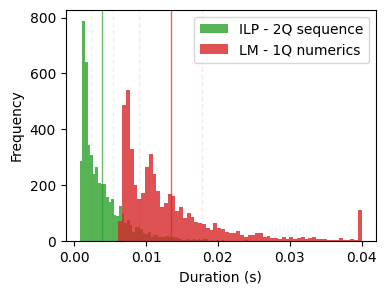

In [45]:
# duration historams
fig, ax = plt.subplots(1, 1, figsize=(4, 3))
bins = 64
amax = 0.04  # 0.05  # 0.08

cmap = plt.colormaps.get_cmap("tab10")

# histogram data and colors
# data = [
#     # (numeric_timings1[1:], "1Q numerics (9 RV)"),
#     (lp_timings1[1:], "highs(ILP)"),
#     (lp_timings2[1:], "cplex(MILP)"),
# ]

data = [
    # (numeric_timings1[1:], "1Q numerics (9 RV)"),
    (lp_timings1[1:], "ILP - 2Q sequence"),
    (numeric_timings1[1:], "LM - 1Q numerics"),
]

for (durations, label), color in zip(data, cmap.colors[2:]):
    clipped_data = np.clip(durations, a_min=0, a_max=amax)
    ax.hist(clipped_data, bins, label=label, alpha=0.8, color=color)
    mean = np.mean(durations)
    std = np.std(durations)

    ax.axvline(mean, color=color, linestyle="-", linewidth=1, alpha=0.7)
    ax.axvline(mean + std / 2.0, color=color, linestyle="--", linewidth=1, alpha=0.1)
    ax.axvline(mean - std / 2.0, color=color, linestyle="--", linewidth=1, alpha=0.1)

ax.set_ylabel("Frequency")
ax.set_xlabel("Duration (s)")
ax.legend()

In [46]:
fig.savefig("lpvsnumerics.svg", bbox_inches="tight")